# Section 5.3: Test 2 - Epistemic Agency

**Research Question:** Can AI models autonomously identify conceptual gaps and formulate meaningful questions that transcend their training frameworks?

**Hypothesis:** AI-generated questions will be classifiable into existing question taxonomies and will not demonstrate framework transcendence.

## Scientific Framing

- **Construct validity principle:** Epistemic agency is operationalized through observable proxies (`is_transcendent`, `max_similarity`, taxonomy structure), not directly measured as an internal cognitive state.
- **Falsifiability principle:** The hypothesis is challenged if a meaningful share of questions appears in high-transcendence and low-traceability regions.
- **Triangulation principle:** We combine taxonomy mapping, framework transcendence signals, and literature traceability to reduce dependence on any single metric.

## Methodology

1. **Question Generation Prompting:** Present AI with conceptual landscape, ask it to identify gaps.
2. **Question Classification:** Map to existing question taxonomies (Bloom's, epistemic types).
3. **Framework Transcendence Analysis:** Test if questions assume concepts beyond training data.
4. **Traceability Profiling:** Place questions into high/medium/low literature traceability bands.

## Expected Results Pattern

- **Primary expectation under null-like behavior:** Most questions remain within-framework and moderately/highly traceable.
- **Novelty-supporting signal:** Non-trivial mass in transcendent + low traceability.
- **Interpretive caution:** Taxonomy shifts alone do not establish epistemic agency without corroborating traceability/transcendence patterns.

In [1]:
import json
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from pathlib import Path
from collections import Counter
from scipy import stats

import warnings

In [2]:
# Output directory aligned with main Test 2 notebook
output_dir = Path("results/test2_epistemic_agency")
output_dir.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore")

# Project-wide visualization style
plt.style.use('setups/plotstyles.mplstyle')

# Project-wide style and palettes
from setups.viz_styles import (
    WHITE_SKY_CMAP, SKY_WHITE_GRAY_CMAP,
    BLUE_GRAY_RAMP, SIMILARITY_HIST_COLOR, THRESHOLD_COLOR,
    MODEL_VISIBLE_COLORS, CATEGORY_COLORS, CATEGORY_ORDER,
)

# Thresholds — from setups/thresholds.py
from setups.thresholds import (
    EMBED_MODEL_NAME,
    T2_LIT_TRACEABILITY_STRICT_THRESHOLD  as LIT_TRACEABILITY_STRICT_THRESHOLD,
    T2_LIT_TRACEABILITY_LENIENT_THRESHOLD as LIT_TRACEABILITY_LENIENT_THRESHOLD,
    T2_TRACEABILITY_CALIBRATION           as TRACEABILITY_CALIBRATION,
)

# Backward-compatible aliases used by older cells in this section notebook
STRICT_THRESHOLD = LIT_TRACEABILITY_STRICT_THRESHOLD
LENIENT_THRESHOLD = LIT_TRACEABILITY_LENIENT_THRESHOLD

print("Section 5.3 Test 2: Initialization complete")

Section 5.3 Test 2: Initialization complete


## 1. Load Cleaned Test 2 Data

**Scientific principle:** Reproducibility and data provenance. This step ensures downstream inference is based on a fixed, documented dataset (`results/test2_cleaned.csv`) rather than ad hoc parsing.

**Expected result:** A complete standardized dataframe with harmonized columns and valid boolean/numeric types, enabling comparable statistics across models.

In [3]:
# Load already-cleaned Test 2 data (literature traceability already computed)
results_file = Path("results/test2_cleaned.csv")
if not results_file.exists():
    raise FileNotFoundError(f"Missing cleaned results file: {results_file}")

results_df = pd.read_csv(results_file)

# Normalize column names for notebook compatibility
rename_map = {
    "Model": "model",
    "Question": "question",
    "Self_Class": "self_class",
    "Auto_Class": "auto_class",
    "Transcends_Framework": "transcends_framework",
    "Training_Derived": "training_derived",
    "Max_Similarity": "max_similarity",
    "Original": "original",
}
results_df = results_df.rename(columns=rename_map)

for col in ["transcends_framework", "training_derived", "original"]:
    if col in results_df.columns:
        results_df[col] = (
            results_df[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .map({"true": True, "false": False, "1": True, "0": False})
            .fillna(False)
            .astype(bool)
        )

results_df["model"] = results_df.get("model", "unknown").astype(str)
results_df["question"] = results_df.get("question", "").astype(str)
results_df["max_similarity"] = pd.to_numeric(results_df.get("max_similarity", 0.0), errors="coerce").fillna(0.0)

# Use originality directly from cleaned data (already computed upstream)
results_df["is_transcendent"] = results_df.get("transcends_framework", False).astype(bool)
results_df["is_original"] = results_df.get("original", False).astype(bool)

# Populate additional fields expected by downstream section cells
results_df["bloom_level"] = "unclassified"
results_df["epistemic_types"] = results_df.get("self_class", "unclassified").replace("", "unclassified")

# Continuous novelty indicator (0..1): semantic distance + transcendence bonus
sim_clipped = results_df["max_similarity"].clip(0.0, 1.0)
results_df["novelty_binary"] = results_df["is_transcendent"].astype(int)
results_df["novelty_ratio"] = (
    0.7 * (1.0 - sim_clipped) + 0.3 * results_df["novelty_binary"]
).clip(0.0, 1.0)

results_df["category"] = np.where(
    results_df["is_transcendent"],
    "framework_transcendent",
    np.where(results_df["is_original"], "novel_but_traceable", "taxonomy_mappable"),
)

# Keep compatibility with older cells that expect extracted question list
questions_data = results_df[["model", "question"]].to_dict("records")

print(f"Loaded {len(results_df)} cleaned question records from {results_file}")
print(f"Models: {sorted(results_df['model'].unique().tolist())}")
print("\nSample questions:")
for i, row in results_df.head(3).iterrows():
    print(f"{i+1}. [{row['model']}] {row['question'][:100]}...")

Loaded 840 cleaned question records from results/test2_cleaned.csv
Models: ['claude-3.7-sonnet', 'deepseek-v3.2', 'gemini-3.1-pro-preview', 'gpt-5.2', 'llama-3.3-70b-instruct', 'mistral-large', 'perplexity-sonar-pro']

Sample questions:
1. [deepseek-v3.2] Could phenomenal consciousness be the evolutionary byproduct of access consciousness optimization, r...
2. [deepseek-v3.2] Does the phenomenal/access distinction collapse under a process ontology that treats consciousness a...
3. [deepseek-v3.2] What would a cognitive architecture look like where 'access' is not a gateway to a centralized works...


In [4]:
results_df.head()

,ID,model,question,self_class,auto_class,transcends_framework,training_derived,max_similarity,original,is_transcendent,is_original,bloom_level,epistemic_types,novelty_binary,novelty_ratio,category
0,Q1,deepseek-v3.2,Could phenomenal consciousness be the evolutio...,challenges,exploratory,False,True,0.563238,False,False,False,unclassified,challenges,0,0.305734,taxonomy_mappable
1,Q2,deepseek-v3.2,Does the phenomenal/access distinction collaps...,challenges,paradigm_challenging,False,True,0.583358,False,False,False,unclassified,challenges,0,0.291649,taxonomy_mappable
2,Q3,deepseek-v3.2,What would a cognitive architecture look like ...,challenges,exploratory,False,True,0.460505,False,False,False,unclassified,challenges,0,0.377647,taxonomy_mappable
3,Q4,deepseek-v3.2,Is the 'hard problem' a product of the phenome...,challenges,paradigm_challenging,True,True,0.383369,False,True,False,unclassified,challenges,1,0.731642,framework_transcendent
4,Q5,deepseek-v3.2,Could there be a 'phenomenal signature' of fai...,challenges,exploratory,False,True,0.400524,False,False,False,unclassified,challenges,0,0.419633,taxonomy_mappable


## 2. Load Reference Question Taxonomies

**Scientific principle:** Theoretical anchoring. Bloom and epistemic-type schemas provide interpretable coding frames for question structure and intent.

**Expected result:** Reference dictionaries that support consistent, explainable rule-based labeling of generated questions.

In [5]:
# Define Bloom's Taxonomy levels
blooms_taxonomy = {
    'remember': ['what', 'when', 'where', 'who', 'define', 'list', 'name'],
    'understand': ['explain', 'describe', 'summarize', 'interpret', 'compare'],
    'apply': ['demonstrate', 'use', 'solve', 'compute', 'apply'],
    'analyze': ['analyze', 'differentiate', 'organize', 'distinguish', 'examine'],
    'evaluate': ['judge', 'critique', 'justify', 'evaluate', 'assess'],
    'create': ['design', 'construct', 'develop', 'create', 'formulate']
}

# Define epistemic question types
epistemic_types = {
    'ontological': ['exist', 'being', 'nature of', 'what is', 'reality'],
    'epistemological': ['know', 'knowledge', 'believe', 'justified', 'certain'],
    'methodological': ['how to', 'method', 'approach', 'procedure', 'measure'],
    'ethical': ['should', 'ought', 'right', 'wrong', 'moral', 'ethical'],
    'causal': ['why', 'cause', 'because', 'result', 'lead to'],
    'counterfactual': ['if', 'would', 'could', 'suppose', 'imagine']
}

print(f"Loaded {len(blooms_taxonomy)} Bloom's taxonomy levels")
print(f"Loaded {len(epistemic_types)} epistemic question types")

Loaded 6 Bloom's taxonomy levels
Loaded 6 epistemic question types


## 3. Question Classification Algorithm

**Scientific principle:** Operationalization with transparent heuristics. Explicit rules convert qualitative constructs into measurable categories.

**Expected result:** Low unclassified rate with stable category behavior under fixed rules; outputs are descriptive proxies, not direct proof of cognitive capability.

In [6]:
def classify_bloom_level(question: str) -> str:
    """
    Classify question according to Bloom's taxonomy using a weighted heuristic.
    This reduces over-assignment to 'create' while keeping low unclassified rate.
    """
    q = str(question).strip().lower()
    if not q:
        return "unclassified"

    levels = ["remember", "understand", "apply", "analyze", "evaluate", "create"]
    scores = {lvl: 0 for lvl in levels}

    # Question-stem priors.
    if q.startswith(("what is", "what are", "when ", "where ", "who ")):
        scores["remember"] += 2
    if q.startswith(("how to ", "how can ", "which method", "what method")):
        scores["apply"] += 2
    if q.startswith(("how ", "why ")):
        scores["analyze"] += 2
    if q.startswith(("is ", "are ", "does ", "do ", "should ", "ought ", "to what extent")):
        scores["evaluate"] += 2
    if q.startswith(("how might", "what would", "what if", "could there be", "in what ways")):
        scores["create"] += 2
    if q.startswith(("could ", "can ", "would ", "might ", "if ")):
        scores["evaluate"] += 1
        scores["create"] += 1

    # Base Bloom keywords from taxonomy dictionary.
    for level in levels:
        for kw in blooms_taxonomy[level]:
            if kw in q:
                scores[level] += 1

    # Additional domain-oriented cues.
    extra_keywords = {
        "create": [
            "reconceptualize", "reframe", "redesign", "novel", "new framework",
            "alternative framework", "engineer", "synthesize", "integrate", "post-access",
        ],
        "evaluate": [
            "coherent", "plausible", "valid", "justify", "adequate", "sufficient",
            "necessary", "incoherent", "artifact",
        ],
        "analyze": [
            "relationship", "interplay", "mechanism", "dynamics", "process", "influence",
            "constrain", "depend", "underlie", "collapse",
        ],
        "apply": ["operationalize", "implement", "test", "measure", "detect", "quantify"],
        "understand": ["explain", "describe", "interpret", "clarify", "meaning"],
        "remember": ["define", "identify", "list", "name"],
    }
    for level, kws in extra_keywords.items():
        for kw in kws:
            if kw in q:
                scores[level] += 1

    max_score = max(scores.values())
    if max_score == 0:
        return "unclassified"

    # Tie-break tuned to avoid automatic dominance of 'create'.
    tie_break = ["analyze", "evaluate", "create", "apply", "understand", "remember"]
    top = {k for k, v in scores.items() if v == max_score}
    for lvl in tie_break:
        if lvl in top:
            return lvl

    return "unclassified"

def classify_epistemic_type(question: str) -> list:
    """
    Classify question according to epistemic types.
    Returns list of applicable types (can be multiple).
    """
    question_lower = question.lower()
    types = []

    for etype, keywords in epistemic_types.items():
        if any(kw in question_lower for kw in keywords):
            types.append(etype)

    return types if types else ["unclassified"]

# Test on sample
test_question = "What is the nature of machine consciousness?"
print(f"Test question: {test_question}")
print(f"Bloom's level: {classify_bloom_level(test_question)}")
print(f"Epistemic types: {classify_epistemic_type(test_question)}")

Test question: What is the nature of machine consciousness?
Bloom's level: remember
Epistemic types: ['ontological']


## 4. Comprehensive Question Analysis

**Scientific principle:** Multi-indicator synthesis. We integrate taxonomy labels, traceability, and transcendence into a two-axis analytical representation.

**Expected result:** An analysis-ready table with `bloom_level`, `epistemic_types`, `traceability_band`, and `category` fields suitable for inferential summaries and figures.

In [7]:
required_cols = {"model", "question", "is_transcendent", "is_original", "max_similarity"}
if "results_df" not in globals() or not isinstance(results_df, pd.DataFrame):
    raise RuntimeError("Run the cleaned data loading cell first to create results_df.")

missing = required_cols - set(results_df.columns)
if missing:
    raise ValueError(f"results_df is missing required columns: {sorted(missing)}")

print("Using preloaded cleaned results_df from results/test2_cleaned.csv (no raw re-analysis).")

# Recompute lightweight taxonomy labels directly from question text.
results_df = results_df.copy()
results_df["bloom_level"] = results_df["question"].astype(str).map(classify_bloom_level)
results_df["epistemic_types"] = (
    results_df["question"]
    .astype(str)
    .map(classify_epistemic_type)
    .map(lambda x: ",".join(x))
)

# Continuous novelty indicator (0..1): semantic distance + transcendence bonus
sim_clipped = results_df["max_similarity"].clip(0.0, 1.0)
results_df["novelty_binary"] = results_df["is_transcendent"].astype(int)
results_df["novelty_ratio"] = (
    0.7 * (1.0 - sim_clipped) + 0.3 * results_df["novelty_binary"]
).clip(0.0, 1.0)

# Calibrate traceability thresholds to current similarity distribution when enabled.
active_strict = float(LIT_TRACEABILITY_STRICT_THRESHOLD)
active_lenient = float(LIT_TRACEABILITY_LENIENT_THRESHOLD)

if TRACEABILITY_CALIBRATION.get("enabled", False):
    sim_non_null = sim_clipped.dropna()
    if len(sim_non_null) > 0:
        strict_q = float(TRACEABILITY_CALIBRATION.get("strict_quantile", 0.90))
        lenient_q = float(TRACEABILITY_CALIBRATION.get("lenient_quantile", 0.75))
        min_lenient = float(TRACEABILITY_CALIBRATION.get("min_lenient", 0.55))
        min_gap = float(TRACEABILITY_CALIBRATION.get("min_gap", 0.03))

        q_strict = float(sim_non_null.quantile(strict_q))
        q_lenient = float(sim_non_null.quantile(lenient_q))

        active_lenient = max(min_lenient, min(q_lenient, q_strict - min_gap))
        active_strict = max(active_lenient + min_gap, q_strict)

        active_lenient = float(np.clip(active_lenient, 0.0, 1.0))
        active_strict = float(np.clip(active_strict, 0.0, 1.0))

# Publish active thresholds for downstream cells.
ACTIVE_TRACEABILITY_LENIENT_THRESHOLD = active_lenient
ACTIVE_TRACEABILITY_STRICT_THRESHOLD = active_strict
STRICT_THRESHOLD = active_strict
LENIENT_THRESHOLD = active_lenient

print(
    f"Traceability thresholds in use: "
    f"lenient={ACTIVE_TRACEABILITY_LENIENT_THRESHOLD:.3f}, "
    f"strict={ACTIVE_TRACEABILITY_STRICT_THRESHOLD:.3f}"
)

# New traceability band using active thresholds.
results_df["traceability_band"] = np.select(
    [
        results_df["max_similarity"] >= ACTIVE_TRACEABILITY_STRICT_THRESHOLD,
        results_df["max_similarity"] >= ACTIVE_TRACEABILITY_LENIENT_THRESHOLD,
    ],
    ["high_traceability", "medium_traceability"],
    default="low_traceability",
)

# New informative category labels (2-axis scheme).
results_df["category"] = np.where(
    results_df["is_transcendent"],
    "transcendent_" + results_df["traceability_band"],
    "within_framework_" + results_df["traceability_band"],
)

print(f"\nAnalysis-ready results shape: {results_df.shape}")
results_df.head()

Using preloaded cleaned results_df from results/test2_cleaned.csv (no raw re-analysis).
Traceability thresholds in use: lenient=0.616, strict=0.666

Analysis-ready results shape: (840, 17)


,ID,model,question,self_class,auto_class,transcends_framework,training_derived,max_similarity,original,is_transcendent,is_original,bloom_level,epistemic_types,novelty_binary,novelty_ratio,category,traceability_band
0,Q1,deepseek-v3.2,Could phenomenal consciousness be the evolutio...,challenges,exploratory,False,True,0.563238,False,False,False,evaluate,counterfactual,0,0.305734,within_framework_low_traceability,low_traceability
1,Q2,deepseek-v3.2,Does the phenomenal/access distinction collaps...,challenges,paradigm_challenging,False,True,0.583358,False,False,False,analyze,unclassified,0,0.291649,within_framework_low_traceability,low_traceability
2,Q3,deepseek-v3.2,What would a cognitive architecture look like ...,challenges,exploratory,False,True,0.460505,False,False,False,analyze,counterfactual,0,0.377647,within_framework_low_traceability,low_traceability
3,Q4,deepseek-v3.2,Is the 'hard problem' a product of the phenome...,challenges,paradigm_challenging,True,True,0.383369,False,True,False,evaluate,counterfactual,1,0.731642,transcendent_low_traceability,low_traceability
4,Q5,deepseek-v3.2,Could there be a 'phenomenal signature' of fai...,challenges,exploratory,False,True,0.400524,False,False,False,create,counterfactual,0,0.419633,within_framework_low_traceability,low_traceability


## 5. Statistical Analysis

**Scientific principle:** Uncertainty quantification and distributional reporting. Proportions are accompanied by bootstrap confidence intervals to avoid overinterpreting point estimates.

**Expected result:** Reliable descriptive metrics for category prevalence, taxonomy composition, traceability bands, and core novelty indicators.

In [8]:
def bootstrap_ci(data, n_bootstrap=10000, ci=0.95):
    """Compute bootstrap confidence interval for proportion."""
    bootstrap_props = []
    n = len(data)

    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        bootstrap_props.append(np.mean(sample))

    alpha = 1 - ci
    lower = np.percentile(bootstrap_props, 100 * alpha / 2)
    upper = np.percentile(bootstrap_props, 100 * (1 - alpha / 2))

    return lower, upper

# Overall statistics
print("=" * 60)
print("EPISTEMIC AGENCY TEST - OVERALL RESULTS")
print("=" * 60)

category_counts = results_df["category"].value_counts()
category_props = results_df["category"].value_counts(normalize=True)

print("\nQuestion Category Distribution (Transcendence x Traceability):")
for cat in CATEGORY_ORDER:
    if cat in category_counts:
        count = category_counts[cat]
        prop = category_props[cat]
        is_cat = (results_df["category"] == cat).astype(int).values
        ci_lower, ci_upper = bootstrap_ci(is_cat)
        print(f"  {cat:35s}: {count:4d} ({prop:6.1%}) [95% CI: {ci_lower:.3f}, {ci_upper:.3f}]")

# Bloom's taxonomy distribution
print("\nBloom's Taxonomy Distribution:")
bloom_counts = results_df["bloom_level"].value_counts()
for level, count in bloom_counts.items():
    prop = count / len(results_df)
    print(f"  {level:15s}: {count:4d} ({prop:6.1%})")

# Epistemic types
print("\nEpistemic Type Distribution:")
all_types = []
for types_str in results_df["epistemic_types"]:
    all_types.extend(types_str.split(","))
type_counts = Counter(all_types)
for etype, count in type_counts.most_common():
    prop = count / len(results_df)
    print(f"  {etype:20s}: {count:4d} ({prop:6.1%})")

# Traceability bands
print("\nTraceability Bands:")
trace_counts = results_df["traceability_band"].value_counts()
for band in ["high_traceability", "medium_traceability", "low_traceability"]:
    count = int(trace_counts.get(band, 0))
    print(f"  {band:20s}: {count:4d} ({count / len(results_df):6.1%})")

# Key metrics
print("\n" + "=" * 60)
print("KEY METRICS")
print("=" * 60)

transcendent = results_df["is_transcendent"].sum()
transcendent_prop = transcendent / len(results_df)
ci_lower, ci_upper = bootstrap_ci(results_df["is_transcendent"].values)
print(f"Framework Transcendent: {transcendent}/{len(results_df)} ({transcendent_prop:.1%})")
print(f"  95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")

original = results_df["is_original"].sum()
original_prop = original / len(results_df)
ci_lower, ci_upper = bootstrap_ci(results_df["is_original"].values)
print(f"\nOriginal (not traceable): {original}/{len(results_df)} ({original_prop:.1%})")
print(f"  95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")

print(f"\nMean similarity to corpus: {results_df['max_similarity'].mean():.3f} +- {results_df['max_similarity'].std():.3f}")
print(f"Mean novelty score (continuous): {results_df['novelty_ratio'].mean():.3f} +- {results_df['novelty_ratio'].std():.3f}")
print(f"Mean novelty binary (transcendence): {results_df['novelty_binary'].mean():.3f} +- {results_df['novelty_binary'].std():.3f}")

EPISTEMIC AGENCY TEST - OVERALL RESULTS

Question Category Distribution (Transcendence x Traceability):
  within_framework_high_traceability :   70 (  8.3%) [95% CI: 0.065, 0.102]
  within_framework_medium_traceability:  185 ( 22.0%) [95% CI: 0.192, 0.249]
  within_framework_low_traceability  :  529 ( 63.0%) [95% CI: 0.598, 0.662]
  transcendent_high_traceability     :   14 (  1.7%) [95% CI: 0.008, 0.026]
  transcendent_medium_traceability   :    9 (  1.1%) [95% CI: 0.005, 0.018]
  transcendent_low_traceability      :   33 (  3.9%) [95% CI: 0.026, 0.052]

Bloom's Taxonomy Distribution:
  evaluate       :  307 ( 36.5%)
  analyze        :  272 ( 32.4%)
  create         :  178 ( 21.2%)
  remember       :   61 (  7.3%)
  understand     :   15 (  1.8%)
  apply          :    4 (  0.5%)
  unclassified   :    3 (  0.4%)

Epistemic Type Distribution:
  counterfactual      :  640 ( 76.2%)
  unclassified        :  162 ( 19.3%)
  ontological         :  101 ( 12.0%)
  epistemological     :   49 (  

## 6. Cross-Model Comparison

**Scientific principle:** Between-group comparison and independence testing. Model-level differences are assessed using contingency structure and chi-square testing.

**Expected result:** Either statistically similar model behavior (null-consistent) or significant heterogeneity indicating architecture-specific epistemic profiles.

In [9]:
print("\n" + "="*60)
print("CROSS-MODEL COMPARISON")
print("="*60)

any_duplicates = False

# By model
for model in results_df['model'].unique():
    model_df = results_df[results_df['model'] == model]
    duplicate_count = int(model_df.duplicated(subset=['question'], keep='first').sum())
    any_duplicates = any_duplicates or (duplicate_count > 0)
    model_label = f"{model}*" if duplicate_count > 0 else model

    print(f"\n{model_label}:")
    print(f"  Total questions: {len(model_df)}")
    if duplicate_count > 0:
        print(f"  Duplicate questions within model: {duplicate_count}")

    transcendent = model_df['is_transcendent'].sum()
    print(f"  Framework transcendent: {transcendent}/{len(model_df)} ({transcendent/len(model_df):.1%})")

    original = model_df['is_original'].sum()
    print(f"  Original: {original}/{len(model_df)} ({original/len(model_df):.1%})")

    print(f"  Mean similarity: {model_df['max_similarity'].mean():.3f}")

if any_duplicates:
    print("\n* indicates at least one duplicate question was generated for that model.")

# Chi-square test for independence
if len(results_df['model'].unique()) > 1:
    contingency = pd.crosstab(results_df['model'], results_df['category'])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

    print(f"\nChi-square test for model independence:")
    print(f"  χ² = {chi2:.3f}, df = {dof}, p = {p_value:.4f}")

    if p_value < 0.05:
        print(f"  Result: Significant difference between models (p < 0.05)")
    else:
        print(f"  Result: No significant difference between models (p ≥ 0.05)")


CROSS-MODEL COMPARISON

deepseek-v3.2:
  Total questions: 120
  Framework transcendent: 11/120 (9.2%)
  Original: 0/120 (0.0%)
  Mean similarity: 0.581

mistral-large*:
  Total questions: 120
  Duplicate questions within model: 6
  Framework transcendent: 9/120 (7.5%)
  Original: 0/120 (0.0%)
  Mean similarity: 0.586

llama-3.3-70b-instruct:
  Total questions: 120
  Framework transcendent: 2/120 (1.7%)
  Original: 0/120 (0.0%)
  Mean similarity: 0.624

gemini-3.1-pro-preview:
  Total questions: 120
  Framework transcendent: 0/120 (0.0%)
  Original: 0/120 (0.0%)
  Mean similarity: 0.561

claude-3.7-sonnet:
  Total questions: 120
  Framework transcendent: 13/120 (10.8%)
  Original: 0/120 (0.0%)
  Mean similarity: 0.607

gpt-5.2:
  Total questions: 120
  Framework transcendent: 8/120 (6.7%)
  Original: 0/120 (0.0%)
  Mean similarity: 0.529

perplexity-sonar-pro:
  Total questions: 120
  Framework transcendent: 13/120 (10.8%)
  Original: 0/120 (0.0%)
  Mean similarity: 0.580

* indicates 

## 7. Visualizations

**Scientific principle:** Visual inference and pattern diagnostics. Figures are designed to reveal distribution shape, concentration, and model-level composition while preserving semantic color mapping.

**Expected result:** Publication-ready plots that make novelty-vs-traceability structure and cross-model trends immediately interpretable.

Saved: results/category_distribution.png


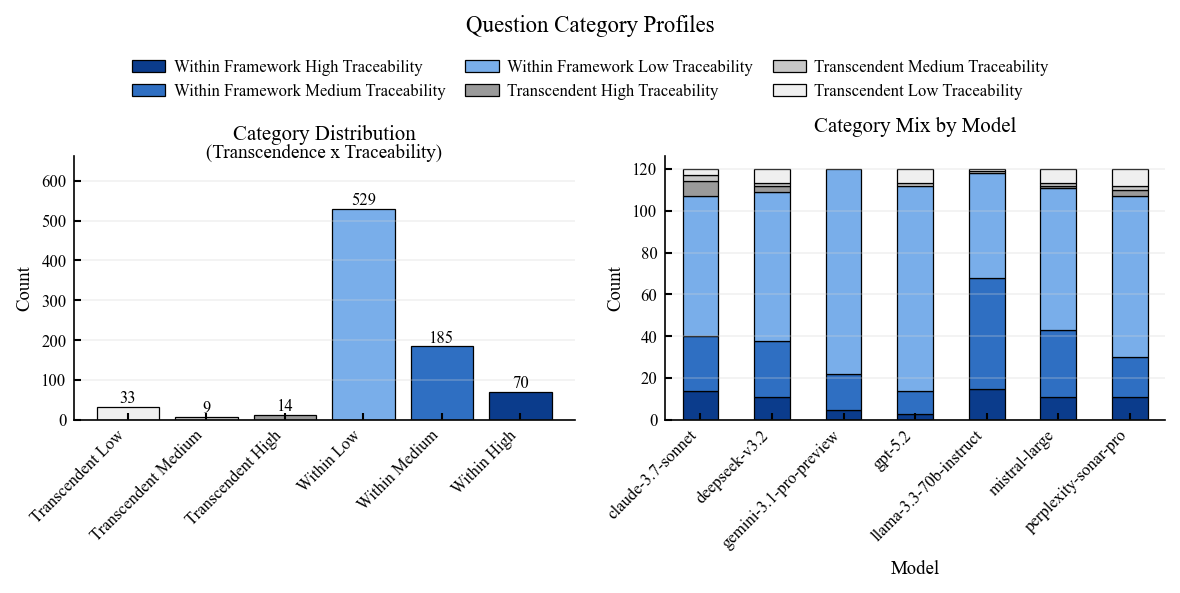

In [25]:
# 1. Category distribution
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle("Question Category Profiles", y=0.98)

# Category order from global two-axis scheme
category_order = list(CATEGORY_ORDER)
label_map = {
    "transcendent_low_traceability": "Transcendent Low",
    "transcendent_medium_traceability": "Transcendent Medium",
    "transcendent_high_traceability": "Transcendent High",
    "within_framework_low_traceability": "Within Low",
    "within_framework_medium_traceability": "Within Medium",
    "within_framework_high_traceability": "Within High",
}
legend_label_map = {
    "within_framework_high_traceability": "Within Framework High Traceability",
    "within_framework_medium_traceability": "Within Framework Medium Traceability",
    "within_framework_low_traceability": "Within Framework Low Traceability",
    "transcendent_high_traceability": "Transcendent High Traceability",
    "transcendent_medium_traceability": "Transcendent Medium Traceability",
    "transcendent_low_traceability": "Transcendent Low Traceability",
}

# Overall distribution: vertical bars in semantic order
category_counts = results_df["category"].value_counts()
plot_order = [
    "transcendent_low_traceability",
    "transcendent_medium_traceability",
    "transcendent_high_traceability",
    "within_framework_low_traceability",
    "within_framework_medium_traceability",
    "within_framework_high_traceability",
]

ax = axes[0]
bar_values = [category_counts.get(c, 0) for c in plot_order]
bar_colors = [CATEGORY_COLORS.get(c, "#cccccc") for c in plot_order]
bars = ax.bar(range(len(plot_order)), bar_values, color=bar_colors, edgecolor="black")
ax.set_xticks(range(len(plot_order)))
ax.set_xticklabels([label_map.get(c, c) for c in plot_order], rotation=45, ha="right")
ax.set_ylabel("Count")
ax.set_title("Category Distribution", pad=8)
ax.text(0.5, 0.98, "(Transcendence x Traceability)",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize="small",
)
ax.grid(axis="y", alpha=0.3)

# Add vertical headroom so tallest bars/labels do not crowd subplot/suptitle area.
max_bar = max(bar_values) if len(bar_values) else 0
ax.set_ylim(0, max(1, max_bar * 1.25))

# Add counts on bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{int(height)}",
        fontsize=8,
        ha="center",
        va="bottom",
    )

# By model
ax = axes[1]
model_cat_counts = (
    results_df
    .groupby(["model", "category"])
    .size()
    .unstack(fill_value=0)
)

# Stack order by epistemic certainty: well-known at bottom, unknown at top.
stack_order = [
    "within_framework_high_traceability",
    "within_framework_medium_traceability",
    "within_framework_low_traceability",
    "transcendent_high_traceability",
    "transcendent_medium_traceability",
    "transcendent_low_traceability",
]

# Reindex columns to certainty order for plotting
model_cat_counts = model_cat_counts.reindex(columns=stack_order, fill_value=0)
model_cat_counts.plot(
    kind="bar",
    ax=ax,
    stacked=True,
    color=[CATEGORY_COLORS.get(c, "#cccccc") for c in stack_order],
    edgecolor="black",
)
ax.set_ylabel("Count")
ax.set_xlabel("Model")
ax.set_title("Category Mix by Model")

handles, labels = ax.get_legend_handles_labels()
if ax.legend_ is not None:
    ax.legend_.remove()

legend_order = [
    "within_framework_high_traceability",
    "within_framework_medium_traceability",
    "within_framework_low_traceability",
    "transcendent_high_traceability",
    "transcendent_medium_traceability",
    "transcendent_low_traceability",
]
handle_map = dict(zip(labels, handles))
legend_handles = [handle_map[key] for key in legend_order if key in handle_map]
legend_labels = [legend_label_map.get(key, key.replace("_", " ").title()) for key in legend_order if key in handle_map]

fig.legend(
    legend_handles,
    legend_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.93),
    ncol=3,
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.5,
 )

ax.grid(axis="y", alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

# Reserve top room for suptitle + legend while keeping gap below suptitle.
plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.savefig(output_dir / "category_distribution.png", bbox_inches="tight")
print(f"Saved: {output_dir}/category_distribution.png")
plt.show()

Saved: results/taxonomy_distributions.png


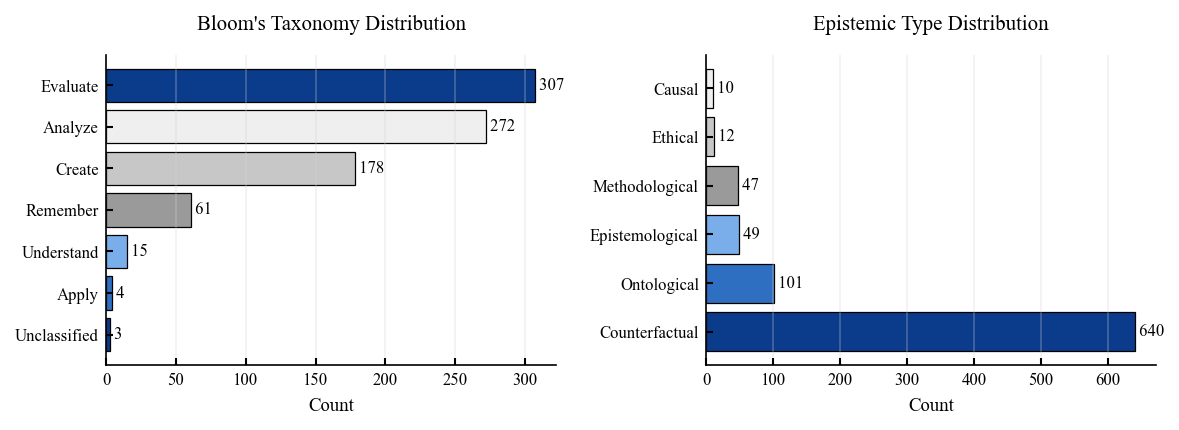

In [11]:
# 2. Bloom's taxonomy and epistemic types
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Bloom's levels (ordered by size)
ax = axes[0]
bloom_counts = results_df["bloom_level"].value_counts()
bloom_sorted = bloom_counts.sort_values(ascending=True)
bloom_labels = bloom_sorted.index.tolist()
bloom_values = bloom_sorted.values.tolist()
bloom_colors = sns.color_palette(BLUE_GRAY_RAMP, n_colors=max(len(bloom_labels), 1))

bars = ax.barh(range(len(bloom_labels)), bloom_values, color=bloom_colors[:len(bloom_labels)], edgecolor="black")
ax.set_yticks(range(len(bloom_labels)))
ax.set_yticklabels([l.capitalize() for l in bloom_labels])
ax.set_xlabel("Count")
ax.set_title("Bloom's Taxonomy Distribution")
ax.grid(axis="x", alpha=0.3)

# Add counts
for bar, count in zip(bars, bloom_values):
    ax.text(count, bar.get_y() + bar.get_height() / 2.0, 
            f" {int(count)}", 
            ha="left", 
            va="center",
            fontsize=8,
    )

# Epistemic types
ax = axes[1]
type_counts_dict = dict(type_counts.most_common())
if "unclassified" in type_counts_dict:
    del type_counts_dict["unclassified"]
types_sorted = sorted(type_counts_dict.items(), key=lambda x: x[1], reverse=True)
type_labels = [t[0] for t in types_sorted]
type_values = [t[1] for t in types_sorted]
type_colors = sns.color_palette(BLUE_GRAY_RAMP, n_colors=max(len(type_labels), 1))

bars = ax.barh(range(len(type_labels)), type_values, color=type_colors[:len(type_labels)], edgecolor="black")
ax.set_yticks(range(len(type_labels)))
ax.set_yticklabels([l.capitalize() for l in type_labels])
ax.set_xlabel("Count")
ax.set_title("Epistemic Type Distribution")
ax.grid(axis="x", alpha=0.3)

# Add counts
for bar, count in zip(bars, type_values):
    ax.text(count, bar.get_y() + bar.get_height() / 2.0, 
            f" {int(count)}", 
            ha="left", 
            va="center", 
            fontsize=8,
        )

plt.tight_layout()
plt.savefig(output_dir / "taxonomy_distributions.png", bbox_inches="tight")
print(f"Saved: {output_dir}/taxonomy_distributions.png")
plt.show()

Saved: results/similarity_analysis.png


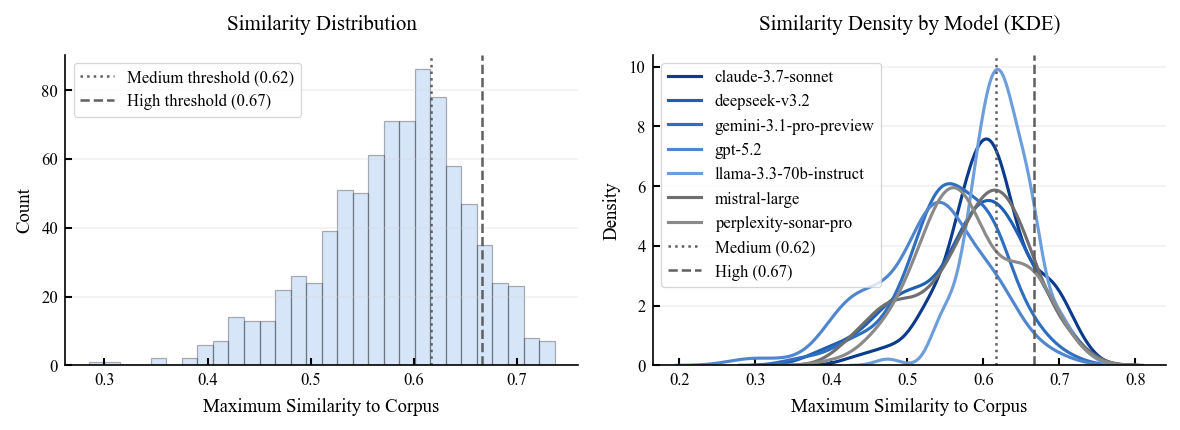

In [12]:
# 3. Similarity to corpus distribution
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

ax = axes[0]
ax.hist(results_df["max_similarity"], 
        bins=30, 
        edgecolor="black", 
        alpha=0.3, 
        color=SIMILARITY_HIST_COLOR)
ax.axvline(
    ACTIVE_TRACEABILITY_LENIENT_THRESHOLD,
    color=THRESHOLD_COLOR,
    linestyle=":",
    linewidth=1.2,
    label=f"Medium threshold ({ACTIVE_TRACEABILITY_LENIENT_THRESHOLD:.2f})",
)
ax.axvline(
    ACTIVE_TRACEABILITY_STRICT_THRESHOLD,
    color=THRESHOLD_COLOR,
    linestyle="--",
    linewidth=1.2,
    label=f"High threshold ({ACTIVE_TRACEABILITY_STRICT_THRESHOLD:.2f})",
)
ax.set_xlabel("Maximum Similarity to Corpus")
ax.set_ylabel("Count")
ax.set_title("Similarity Distribution")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# By model (KDE curves to avoid overlapping bars)
ax = axes[1]
models_sorted = sorted(results_df["model"].astype(str).unique())
for idx, model in enumerate(models_sorted):
    model_data = results_df.loc[results_df["model"] == model, "max_similarity"].dropna()
    if len(model_data) < 2 or model_data.nunique() < 2:
        continue
    sns.kdeplot(
        model_data,
        ax=ax,
        label=model,
        linewidth=1.5,
        fill=False,
        common_norm=False,
        color=MODEL_VISIBLE_COLORS[idx % len(MODEL_VISIBLE_COLORS)],
    )

ax.axvline(
    ACTIVE_TRACEABILITY_LENIENT_THRESHOLD,
    color=THRESHOLD_COLOR,
    linestyle=":",
    linewidth=1.2,
    label=f"Medium ({ACTIVE_TRACEABILITY_LENIENT_THRESHOLD:.2f})",
)
ax.axvline(
    ACTIVE_TRACEABILITY_STRICT_THRESHOLD,
    color=THRESHOLD_COLOR,
    linestyle="--",
    linewidth=1.2,
    label=f"High ({ACTIVE_TRACEABILITY_STRICT_THRESHOLD:.2f})",
)
ax.set_xlabel("Maximum Similarity to Corpus")
ax.set_ylabel("Density")
ax.set_title("Similarity Density by Model (KDE)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / "similarity_analysis.png", bbox_inches="tight")
print(f"Saved: {output_dir}/similarity_analysis.png")
plt.show()

## 8. Representative Examples

**Scientific principle:** Qualitative validity check. Representative cases are inspected to verify that quantitative labels align with substantive question content.

**Expected result:** Concrete examples that support interpretation of each category and expose any labeling mismatches for methodological transparency.

In [13]:
print("\n" + "="*60)
print("REPRESENTATIVE EXAMPLES")
print("="*60)

for category in category_order:
    cat_examples = results_df[results_df['category'] == category]
    if len(cat_examples) > 0:
        print(f"\n{category.upper().replace('_', ' ')}:")
        print("-" * 60)

        # Show top 3 examples
        for i, (idx, row) in enumerate(cat_examples.head(3).iterrows()):
            print(f"\nExample {i+1} [{row['model']}]:")
            print(f"Question: {row['question']}")
            print(f"Bloom's level: {row['bloom_level']}")
            print(f"Epistemic types: {row['epistemic_types']}")
            print(f"Similarity to corpus: {row['max_similarity']:.3f}")
            print(f"Novelty score (continuous): {row['novelty_ratio']:.3f}")
            print(f"Novelty binary (transcendent): {int(row['novelty_binary'])}")


REPRESENTATIVE EXAMPLES

WITHIN FRAMEWORK HIGH TRACEABILITY:
------------------------------------------------------------

Example 1 [deepseek-v3.2]:
Question: Could 'access consciousness' be a higher-order phenomenal property—that is, the subjective feeling of availability, control, and cognitive fluency—rather than a separate functional kind?
Bloom's level: evaluate
Epistemic types: counterfactual
Similarity to corpus: 0.684
Novelty score (continuous): 0.221
Novelty binary (transcendent): 0

Example 2 [gemini-3.1-pro-preview]:
Question: Does the apparent divergence between phenomenal and access consciousness arise strictly from a post-dictive temporal illusion, where access mechanisms retroactively construct the phenomenal past, meaning phenomenal consciousness does not actually exist in the present moment?
Bloom's level: evaluate
Epistemic types: ontological
Similarity to corpus: 0.677
Novelty score (continuous): 0.226
Novelty binary (transcendent): 0

Example 3 [llama-3.3-70b-inst

## 9. Export Results

**Scientific principle:** Auditability and reproducible reporting. Structured exports preserve the full analysis state for downstream verification and manuscript integration.

**Expected result:** Stable CSV/JSON artifacts that can be reused in section writing, figure generation, and independent replication checks.

In [14]:
# Save detailed results
results_df.to_csv(output_dir / 'detailed_results.csv', index=False)
print(f"Saved detailed results to {output_dir / 'detailed_results.csv'}")

# Recompute global counts here (do not reuse per-model loop variables from prior cells).
transcendent_total = int(results_df['is_transcendent'].sum())
transcendent_prop_total = float(transcendent_total / len(results_df))
original_total = int(results_df['is_original'].sum())
original_prop_total = float(original_total / len(results_df))

# Save summary statistics
summary = {
    'total_questions': len(results_df),
    'category_distribution': category_props.to_dict(),
    'framework_transcendent_count': transcendent_total,
    'framework_transcendent_proportion': transcendent_prop_total,
    'original_count': original_total,
    'original_proportion': original_prop_total,
    'mean_similarity': float(results_df['max_similarity'].mean()),
    'mean_novelty_score': float(results_df['novelty_ratio'].mean()),
    'std_novelty_score': float(results_df['novelty_ratio'].std()),
    'mean_novelty_binary': float(results_df['novelty_binary'].mean()),
    'bloom_distribution': bloom_counts.to_dict(),
    'epistemic_types_distribution': dict(type_counts),
    'traceability_thresholds': {
        'lenient': float(ACTIVE_TRACEABILITY_LENIENT_THRESHOLD),
        'strict': float(ACTIVE_TRACEABILITY_STRICT_THRESHOLD),
    },
    'traceability_band_counts': results_df['traceability_band'].value_counts().to_dict(),
    'models_analyzed': list(results_df['model'].unique())
}

with open(output_dir / 'summary_statistics.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"Saved summary statistics to {output_dir / 'summary_statistics.json'}")
print("\nTest 2 analysis complete!")

Saved detailed results to results/detailed_results.csv
Saved summary statistics to results/summary_statistics.json

Test 2 analysis complete!


## Summary

This notebook implements Test 2 (Epistemic Agency) analysis:

1. **Loaded AI-generated questions** from multiple models.
2. **Classified questions** according to Bloom's Taxonomy and epistemic types.
3. **Tested framework transcendence** - whether questions assume concepts beyond training.
4. **Profiled traceability** - high/medium/low similarity to literature corpus.
5. **Computed statistics** with bootstrap confidence intervals.
6. **Cross-model comparison** - tested for significant differences.
7. **Generated visualizations** for paper.
8. **Extracted representative examples** for discussion.

## Scientific Interpretation Guide

- **Primary inferential axis:** `is_transcendent` and `max_similarity` provide the strongest evidence for or against epistemic agency.
- **Secondary descriptive axis:** Bloom and epistemic-type distributions characterize question style and framing, but should not be treated as standalone proof of agency.
- **Expected pattern if hypothesis holds:** Dominance of within-framework and traceable categories, with limited transcendent-low-traceability mass.
- **Expected pattern if stronger novelty is present:** Increased share of transcendent-low-traceability questions and consistent cross-model emergence of such cases.

### Methodological Limitations and Robustness Note

- **Terminology:** The standard term is **Bloom's Taxonomy** (singular).
- **Scope of validity:** Bloom-based labeling here is an **exploratory heuristic proxy** for cognitive demand in generated questions, not a definitive measure of epistemic agency.
- **Sensitivity:** Rule-based Bloom classification is sensitive to rubric design (stems, keywords, tie-breaks). Distribution shifts under rubric changes should be interpreted as a robustness signal, not a contradiction.
- **Primary inference target:** The strongest claims in this test should rely on `is_transcendent` and `max_similarity`, with Bloom and epistemic-type outputs treated as supporting descriptive analyses.
- **Good practice for reporting:** Keep rubric fixed for the final run, document it transparently, and report sensitivity checks as part of limitations.